In [1]:
import numpy as np
import json
from collections import OrderedDict, defaultdict

def reformat_json(
    path: str, 
    reverse=set(),
    keep=None,
):
    """    
    parses the records in a json file (formatted by Evgenia)
    returns a list of records for `judges` (human, NLG eval metric) and another for `systems` (uncertainty quantifiers)

    reverse: name of the quantifiers that need to multiplied by -1 (that is, to turn them into expressions of certainty/confidence)
    keep: use this to keep only some judges
    """    

    with open(path, 'r') as f:
        data = json.load(f)

    sys_rows = defaultdict(list)
    judge_rows = defaultdict(list)
    for record in data:


        # Evgenia stores uncertainty quantifiers under 
        for rater, judgment in record['uncertainty']['uncertainty_scores'].items():             
            if keep is not None and rater not in keep:
                continue
            if isinstance(judgment, str) and judgment.startswith("Confidence:"):
                judgment = judgment.strip("Confidence:")
            score = float(judgment)
            if rater in reverse:
                score = -score
                rater = f"neg_{rater}"
            sys_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': None, 'score': score})
        
        # Evgenia stores human/oracle judgments as key-value pairs in the record's root
        for rater in record.keys():
            if keep is not None and rater not in keep:
                continue
            if rater.startswith('human_judge'):
                label = record[rater].lower() == 'correct'
                judge_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': label, 'score': float(label)})

        # Evgenia stores automated judgments as key-value pairs under 'greedy_correctness'
        for rater, judgment in record['greedy_correctness'].items():                            
            # Some judgments depend on a threshold, Evgenia stores those (and the respective labels) in a dictionary
            if isinstance(judgment, dict):
                for key, value in judgment.items():
                    rater_name = f"{rater}/{key}"
                    if keep is not None and rater_name not in keep:
                        continue
                    label = bool(value)
                    judge_rows[record['id']].append({'id': record['id'], 'rater': rater_name, 'label': label, 'score': float(label)})
            else:
                if keep is not None and rater not in keep:
                    continue
                label = bool(judgment)
                judge_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': label, 'score': float(label)})
        
    return judge_rows, sys_rows


def merge_records(j_data: dict, confidences: list):
    
    data = dict()
    
    for k, v in j_data.items():
        for datum in v:
            record = data.get(datum['id'], None)
            if record is None:
                record = dict()
                data[datum['id']] = record
            record[f"J/{datum['rater']}"] = datum['label']

    
        for datum in confidences:
            record = data.get(datum['item'], None)
            if record is None:
                record = dict()
                data[datum['item']] = record
            record[f"Q/{datum['system']}"] = datum['posterior_confidence']

    return data


Load the data from Evgenia and the confidence from BDA preprocessing and combine everything in dictionaries

In [4]:
import json

experiment = 'ambig_qa_multiple_qas_llama-3b-instruct_100_0'
input_file = f"data/{experiment}.json"
keep = {
    'human_judge1', 
    'human_judge2', 
    'llm_as_judge_gpt-5.4-mini', 
    'llm_as_judge_llama-8b-instruct',
    'exact_match', 
    # 'rouge_l/0.1', 
    'bert_score/0.3', 
    # 'bert_score/0.8', 
    'bert_score/0.9', 
    'log_likelihood_seq', 
    'log_likelihood_token', 
    'entropy', 
    'semantic_entropy', 
    'semantic_confidence', 
    'verbalised_confidence', 
    'p_true'
}
jrows, _ = reformat_json(
    input_file,
    keep=keep
)

with open(f"inferences/{experiment}.confidences.json", 'r') as fp:
    confidences = json.load(fp)

data = merge_records(jrows, confidences)

In [5]:
data['3103857971526342341']

{'J/human_judge1': False,
 'J/exact_match': False,
 'J/bert_score/0.3': True,
 'J/bert_score/0.9': False,
 'J/llm_as_judge_llama-8b-instruct': False,
 'J/llm_as_judge_gpt-5.4-mini': False,
 'Q/entropy': 0.5524125099182129,
 'Q/semantic_entropy': 0.5824418067932129,
 'Q/semantic_confidence': 0.5661848783493042,
 'Q/log_likelihood_seq': 0.6437444686889648,
 'Q/log_likelihood_token': 0.6642353534698486,
 'Q/p_true': 0.46424514055252075,
 'Q/verbalised_confidence': 0.40531814098358154}

Create tables for pandas (there may be easier ways, but my pandas is limited)

In [6]:
import pandas as pd

order = sorted(data.keys())

q_header = ['item', 'quantifier', 'confidence']
j_header = ['item', 'judge', 'label', 'correct', 'category']
q_table = []
j_table = []

oracle_j = 'J/human_judge1'

for uid in order:
    for k, v in sorted(data[uid].items(), key=lambda pair: pair[0]):
        if k.startswith('J/'):
            if data[uid][oracle_j] == v:
                cat = 'TP' if v else 'TN'
            else:
                cat = 'FP' if v else 'FN'
            j_table.append([uid, k, v, data[uid][oracle_j] == v, cat])
        else:
            q_table.append([uid, k, v])

df_q = pd.DataFrame(q_table, columns=q_header)
df_j = pd.DataFrame(j_table, columns=j_header)
df_j

,item,judge,label,correct,category
0,-1062522255440685408,J/bert_score/0.3,True,True,TP
1,-1062522255440685408,J/bert_score/0.9,False,False,FN
2,-1062522255440685408,J/exact_match,False,False,FN
3,-1062522255440685408,J/human_judge1,True,True,TP
4,-1062522255440685408,J/llm_as_judge_gpt-5.4-mini,True,True,TP
...,...,...,...,...,...
595,9175108727427752581,J/bert_score/0.9,False,False,FN
596,9175108727427752581,J/exact_match,False,False,FN
597,9175108727427752581,J/human_judge1,True,True,TP
598,9175108727427752581,J/llm_as_judge_gpt-5.4-mini,True,True,TP


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=0.9)

# Study a specific combination of Judge and Quantifier

<Axes: xlabel='confidence', ylabel='category'>

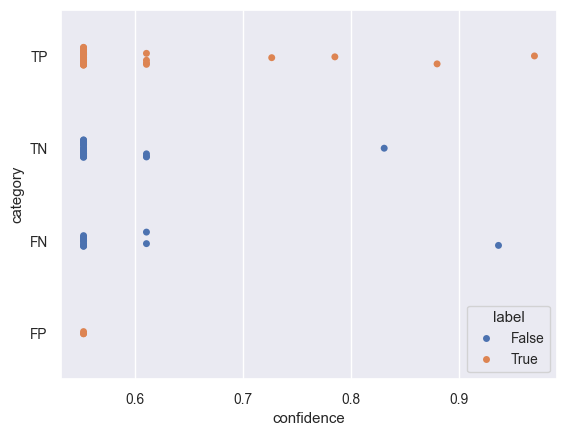

In [8]:
df_ = pd.merge(
    df_q[df_q['quantifier']=='Q/entropy'],
    df_j[df_j['judge']=='J/llm_as_judge_llama-8b-instruct'],
    on='item', how='outer'
)
sns.stripplot(
    data=df_,
    x='confidence',
    y='category',
    hue='label',
)

# Study all Judge-Quantifier pairs

In [9]:
df_qj = pd.merge(
    df_q,
    df_j,
    on='item', how='outer'
)
df_qj

,item,quantifier,confidence,judge,label,correct,category
0,-1062522255440685408,Q/entropy,0.610731,J/bert_score/0.3,True,True,TP
1,-1062522255440685408,Q/entropy,0.610731,J/bert_score/0.9,False,False,FN
2,-1062522255440685408,Q/entropy,0.610731,J/exact_match,False,False,FN
3,-1062522255440685408,Q/entropy,0.610731,J/human_judge1,True,True,TP
4,-1062522255440685408,Q/entropy,0.610731,J/llm_as_judge_gpt-5.4-mini,True,True,TP
...,...,...,...,...,...,...,...
4195,9175108727427752581,Q/verbalised_confidence,0.647672,J/bert_score/0.9,False,False,FN
4196,9175108727427752581,Q/verbalised_confidence,0.647672,J/exact_match,False,False,FN
4197,9175108727427752581,Q/verbalised_confidence,0.647672,J/human_judge1,True,True,TP
4198,9175108727427752581,Q/verbalised_confidence,0.647672,J/llm_as_judge_gpt-5.4-mini,True,True,TP


It takes a few seconds, be patient

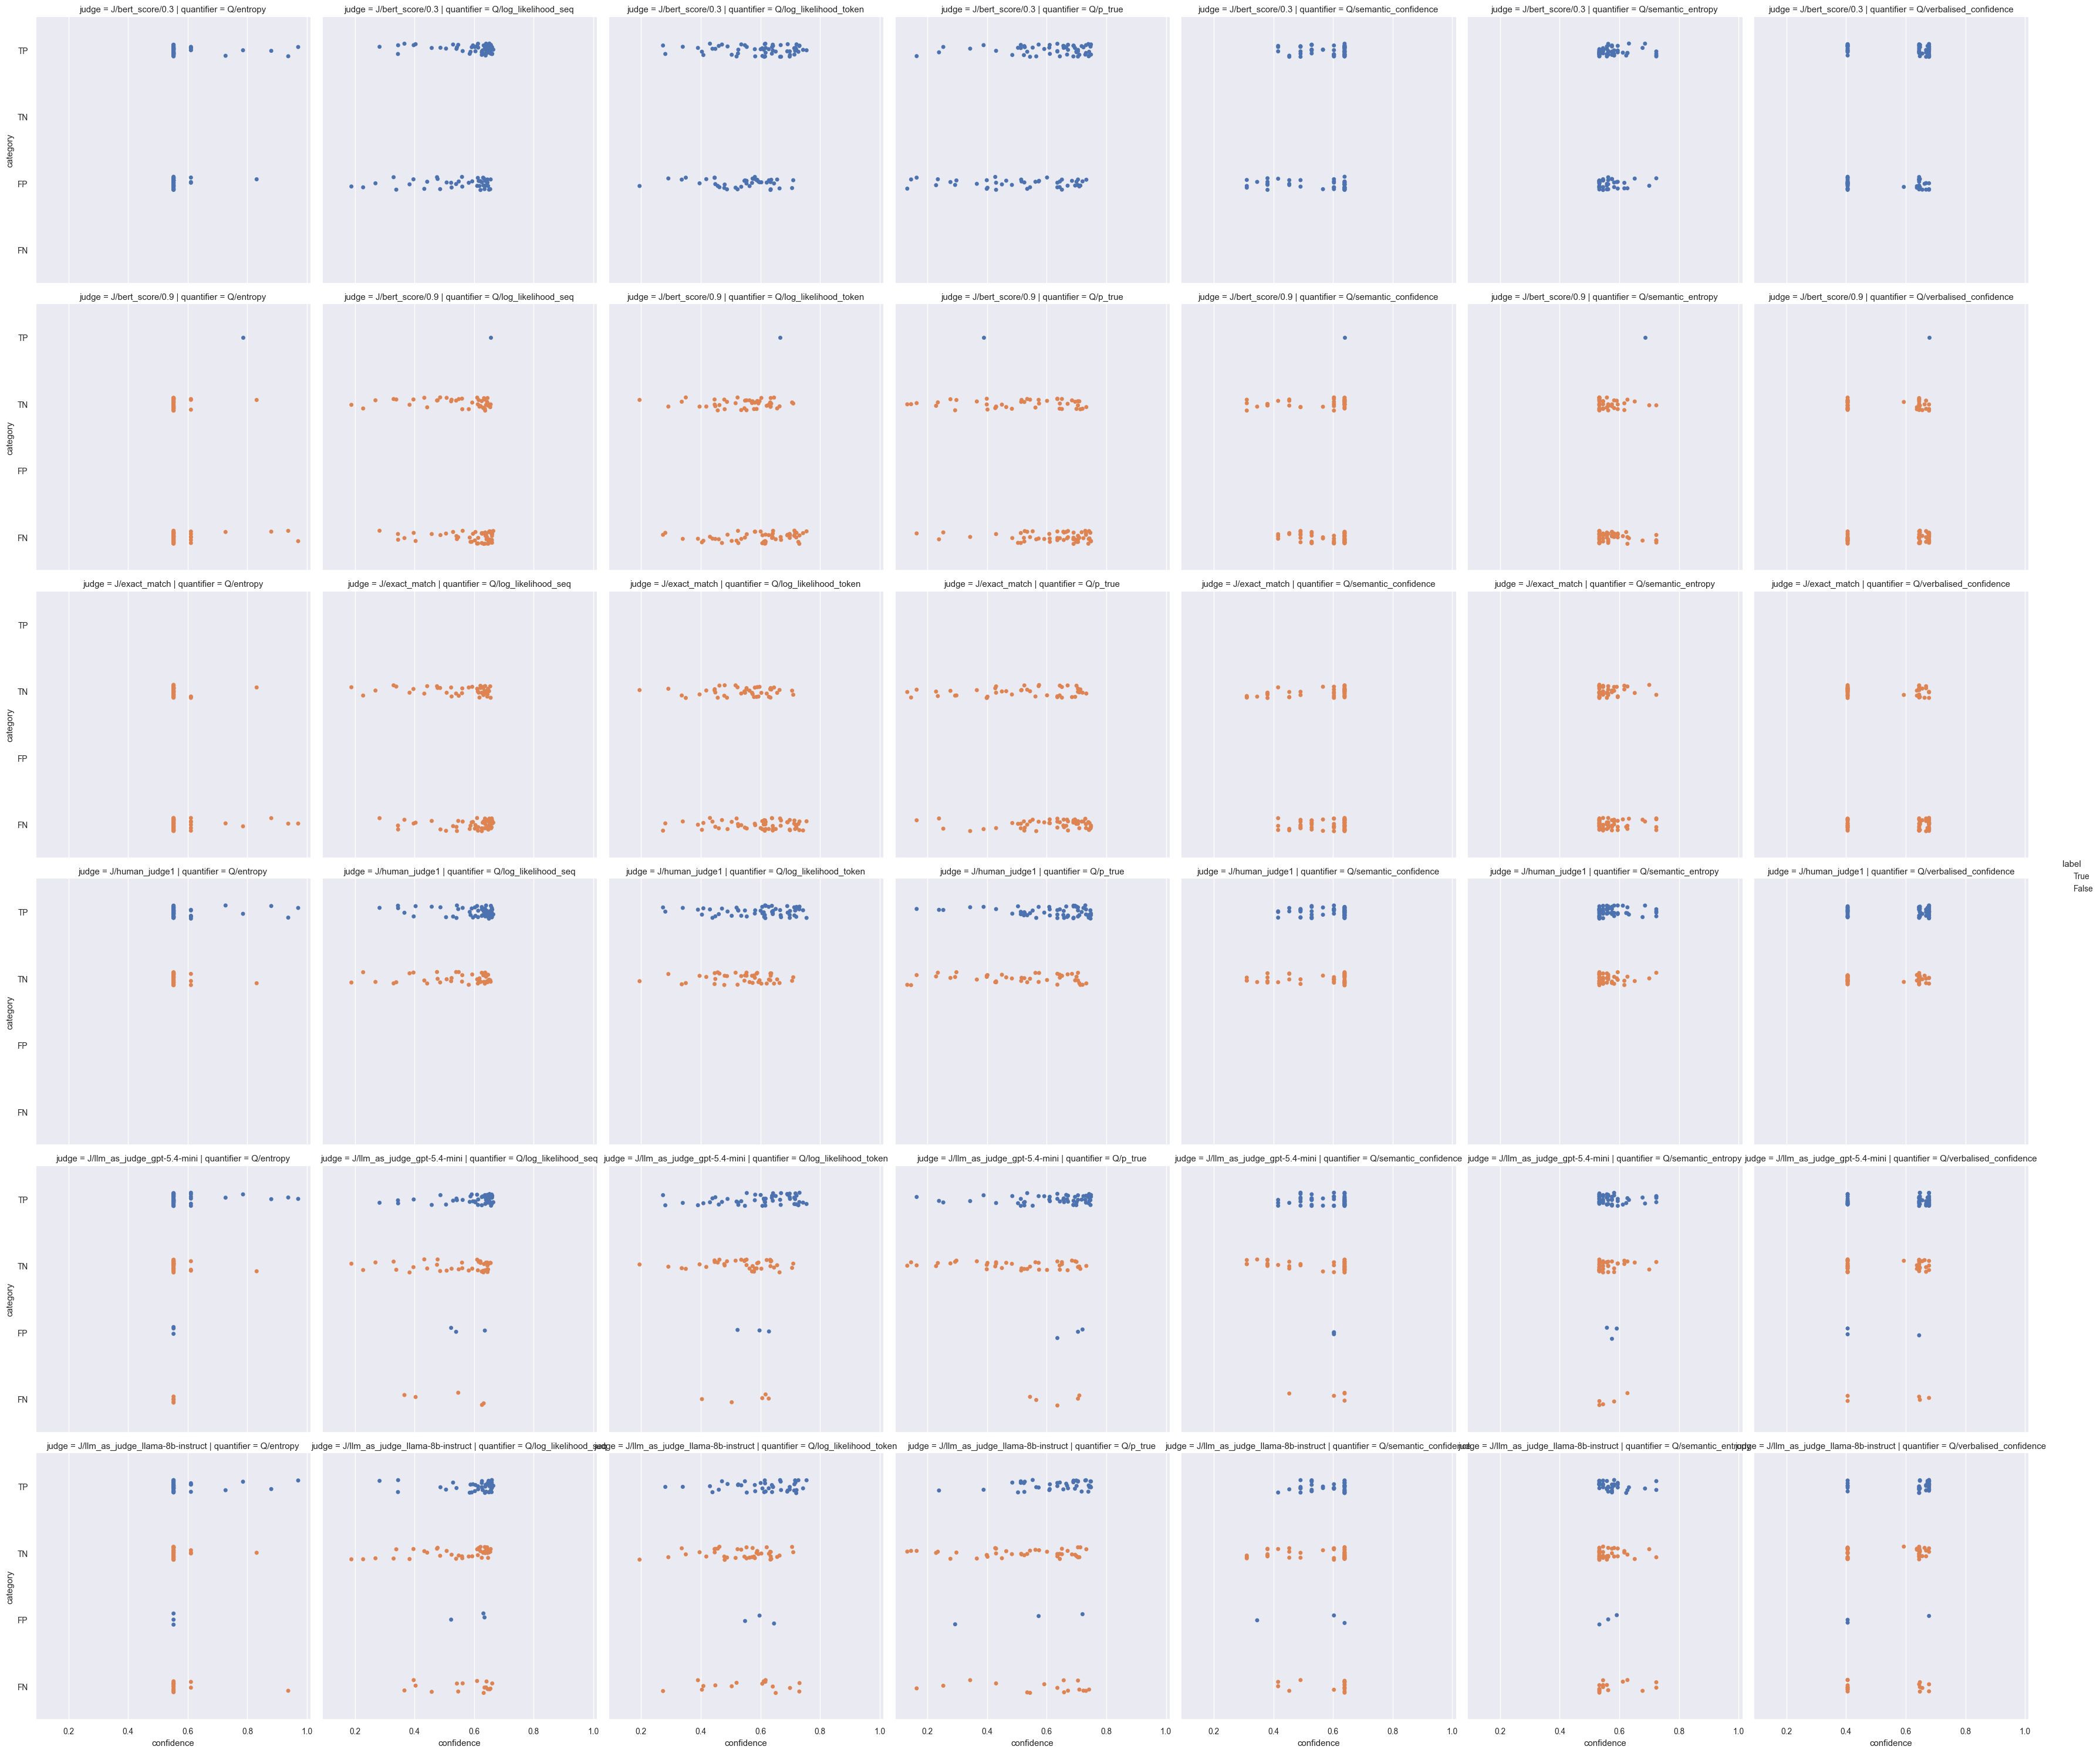

In [10]:
sns.catplot(
    data=df_qj,
    x='confidence',
    y='category',
    hue='label',
    col='quantifier',
    row='judge',
    kind='strip',
    hue_order=[True, False],
    order=['TP', 'TN', 'FP', 'FN']
)